In [1]:
from mmspao.utils import *
from mmspao import mmspao
import scanpy as sc

set_random_seed(42)
device = 'cuda'


In [2]:
#Load data and perform preprocessing
rna = sc.read('/home/data1/linjing0806/multiomics/SWITCH/data/Mouse_embryo/rna_sp.h5ad')
atac = sc.read("/home/data1/linjing0806/multiomics/SWITCH/data/Mouse_embryo/atac_sp.h5ad")
atac.obs_names = [i.split("-")[0] for i in atac.obs_names]
atac = atac[rna.obs_names]
rna.layers["counts"] = rna.X.copy()
sc.pp.highly_variable_genes(rna, n_top_genes=2000, flavor="seurat_v3", layer="counts")
rna =  rna[:, rna.var['highly_variable']]

In [3]:
# get adata.X from rna and atac
atac.layers["counts"] = atac.X.copy()
sc.pp.highly_variable_genes(atac, n_top_genes=2000, flavor="seurat_v3", layer="counts")
atac =  atac[:, atac.var['highly_variable']]
adata = rna.copy()
rna = getX(rna,modality='rna')
atac = getX(atac, modality='atac')

In [4]:
#if using a subset of modality-specific terms, the "sel_views" parameter should be a list with values entries to the indices of the modalities to be included, e.g.,  ind_views=[0,2] if including RNA and image features
#if using a subset of interaction terms, the "combination" parameter should be a list of tuples with entries to the indices of the modalities for each interaction, e.g. combination = [(0,1),(0,2)] if including the RNA-protein and RNA-image interaction terms
model = mmspao([rna,atac],sel_views='all',combination='all',sparse=True, device=device)
model.train(3000)
# np.save('emb.npy', model.emb)

perform PCA for each modality:   0%|          | 0/2 [00:00<?, ?it/s]

sparse adj for each modality:   0%|          | 0/2 [00:00<?, ?it/s]

Training KAN for modality 1:   0%|          | 0/3000 [00:00<?, ?it/s]

Training KAN for modality 2:   0%|          | 0/3000 [00:00<?, ?it/s]

In [5]:
model.cluster(adata, n_domains=13, end=2.0)

Leiden clustering:   0%|          | 0/190 [00:00<?, ?it/s]

Found resolution: 1.54 for 13 domains


1.5399999999999994

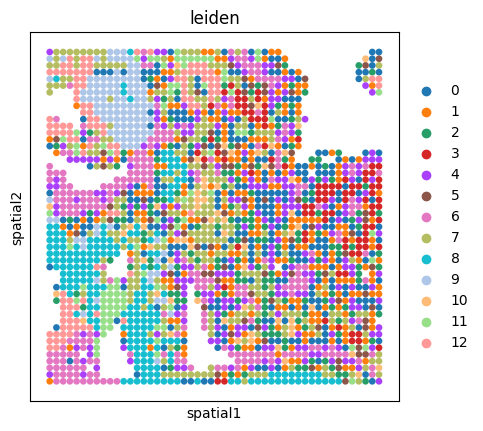

In [6]:
sc.pl.spatial(adata, color="leiden", spot_size=1, show=True)

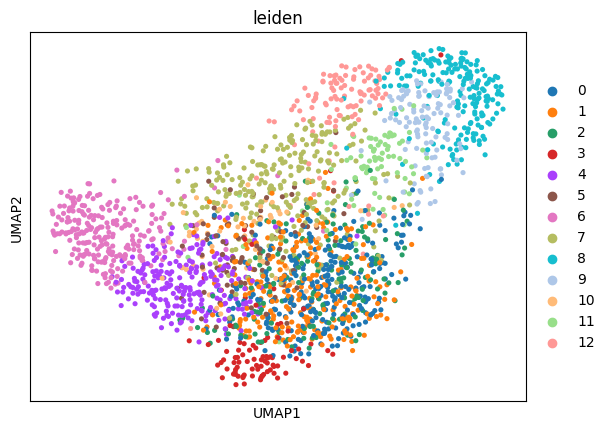

In [7]:
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden",)

In [8]:
{
    'Leiden modularity': model.modularity(adata), # >0.3
    "Moran's I, p_sim": model.moran(adata, k=6), # >0
    "Spatial contiguity ratio": model.contiguity(adata, k=6), # >0.5
}

/home/data1/linjing0806/anaconda3/envs/pytorch_gpu/lib/python3.10/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


{'Leiden modularity': 0.3991050753247347,
 "Moran's I, p_sim": (0.4274144364090433, 0.001),
 'Spatial contiguity ratio': 0.2968297515622618}